# Performance Analysis with Alphalens

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
from pathlib import Path
from collections import defaultdict
from time import time

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from alphalens.tears import (
    create_returns_tear_sheet,
    create_summary_tear_sheet,
    create_full_tear_sheet,
)

from alphalens import plotting
from alphalens import performance as perf
from alphalens import utils

In [4]:
sns.set_style("whitegrid")
np.random.seed(42)
idx = pd.IndexSlice

In [5]:
DATA_STORE = Path("..", "data", "assets.h5")

## Alphalens Analysis

### Load factors

In [11]:
factors = (
    pd.concat(
        [
            pd.read_hdf("data.h5", "factors/common"),
            pd.read_hdf("data.h5", "factors/formulaic").rename(
                columns=lambda x: f"alpha_{int(x):03}"
            ),
        ],
        axis=1,
    )
    .dropna(axis=1, thresh=100000)
    .sort_index()
)

In [12]:
factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1255093 entries, ('A', Timestamp('2007-01-04 00:00:00')) to ('ZION', Timestamp('2016-12-29 00:00:00'))
Columns: 135 entries, sector to alpha_101
dtypes: float64(123), int64(12)
memory usage: 1.3+ GB


### Get trade prices

In [6]:
def get_trade_prices(tickers):
    return (
        pd.read_hdf(DATA_STORE, "quandl/wiki/prices")
        .loc[idx["2006":"2017", tickers], "adj_open"]
        .unstack("ticker")
        .sort_index()
        .shift(-1)
        .tz_localize("UTC")
    )

In [ ]:
tickers = factors.index.get_level_values("ticker").unique()

In [14]:
trade_prices = get_trade_prices(tickers)

In [15]:
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3020 entries, 2006-01-03 00:00:00+00:00 to 2017-12-29 00:00:00+00:00
Columns: 500 entries, A to DPS
dtypes: float64(500)
memory usage: 11.5 MB


In [27]:
alpha = "alpha_001"

In [28]:
factor = (
    factors[alpha]
    .unstack("ticker")
    .stack()
    .tz_localize("UTC", level="date")
    .sort_index()
)

### Generate Alphalens input data

In [34]:
factor_data = utils.get_clean_factor_and_forward_returns(
    factor=factor, prices=trade_prices, quantiles=None, bins=[-0.5, -0.4, -0.3, -0.2, -0.1, 0.0], max_loss=0.35, periods=(1, 5, 10)
).sort_index()
factor_data.info()

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1243838 entries, (Timestamp('2007-01-10 00:00:00+0000', tz='UTC'), 'ABT') to (Timestamp('2016-12-29 00:00:00+0000', tz='UTC'), 'ZION')
Data columns (total 5 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   1D               1243838 non-null  float64
 1   5D               1243838 non-null  float64
 2   10D              1243838 non-null  float64
 3   factor           1243838 non-null  float64
 4   factor_quantile  1243838 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 52.3+ MB


### Compute Metrics

In [35]:
mean_quant_ret_bydate, std_quant_daily = perf.mean_return_by_quantile(
    factor_data,
    by_date=True,
    by_group=False,
    demeaned=True,
    group_adjust=False,
)

mean_quant_rateret_bydate = mean_quant_ret_bydate.apply(
    utils.rate_of_return,
    base_period=mean_quant_ret_bydate.columns[0],
)

compstd_quant_daily = std_quant_daily.apply(
    utils.std_conversion, base_period=std_quant_daily.columns[0]
)

alpha_beta = perf.factor_alpha_beta(factor_data, demeaned=True)

mean_ret_spread_quant, std_spread_quant = perf.compute_mean_returns_spread(
    mean_quant_rateret_bydate,
    factor_data["factor_quantile"].max(),
    factor_data["factor_quantile"].min(),
    std_err=compstd_quant_daily,
)

In [36]:
mean_ret_spread_quant.mean().mul(10000).to_frame("Mean Period Wise Spread (bps)").join(
    alpha_beta.T
).T

,1D,5D,10D
Mean Period Wise Spread (bps),1.426701,1.310822,1.060756
Ann. alpha,0.044110,0.023373,0.011259
beta,0.014458,0.013264,0.014426


### Plot spread and cumulative returns

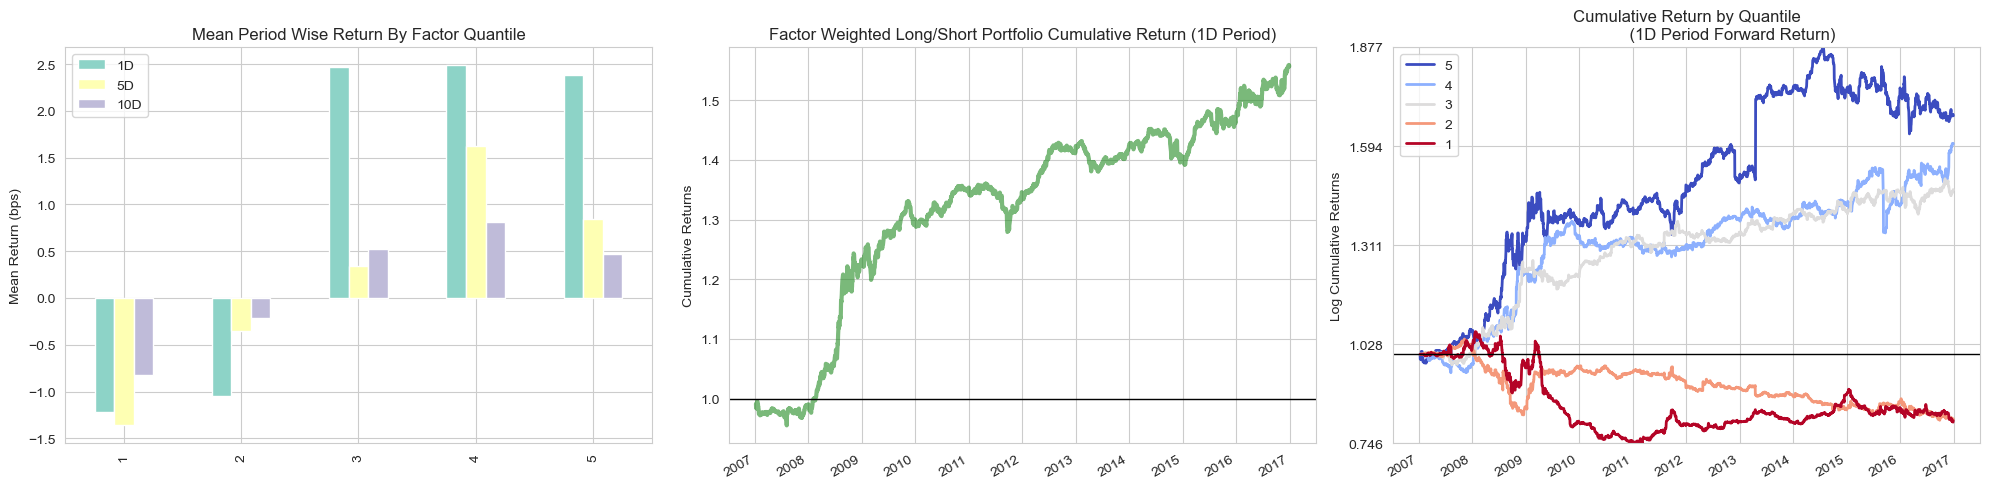

In [37]:
fig, axes = plt.subplots(ncols=3, figsize=(20, 5))

mean_quant_ret, std_quantile = perf.mean_return_by_quantile(
    factor_data, by_group=False, demeaned=True
)

mean_quant_rateret = mean_quant_ret.apply(
    utils.rate_of_return, axis=0, base_period=mean_quant_ret.columns[0]
)

plotting.plot_quantile_returns_bar(mean_quant_rateret, ax=axes[0])

factor_returns = perf.factor_returns(factor_data)

title = "Factor Weighted Long/Short Portfolio Cumulative Return (1D Period)"
plotting.plot_cumulative_returns(
    factor_returns["1D"],
    period="1D",
    freq=pd.tseries.offsets.BDay(),
    title=title,
    ax=axes[1],
)

plotting.plot_cumulative_returns_by_quantile(
    mean_quant_ret_bydate["1D"], freq=pd.tseries.offsets.BDay(), period="1D", ax=axes[2]
)
fig.tight_layout();

### Create Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.499499,-0.400,-0.433596,0.023624,179632,14.441752
2,-0.399899,-0.300,-0.351633,0.028788,346652,27.869546
3,-0.299799,-0.200,-0.251320,0.029626,242861,19.525131
4,-0.199900,-0.100,-0.148809,0.028685,259970,20.900632
5,-0.099900,-0.001,-0.056280,0.025831,214723,17.262939


Returns Analysis


,1D,5D,10D
Ann. alpha,0.044,0.023,0.011
beta,0.014,0.013,0.014
Mean Period Wise Return Top Quantile (bps),2.382,0.841,0.468
Mean Period Wise Return Bottom Quantile (bps),-1.221,-1.362,-0.825
Mean Period Wise Spread (bps),1.427,1.311,1.061


Information Analysis


,1D,5D,10D
IC Mean,0.008,0.007,0.006
IC Std.,0.102,0.099,0.100
Risk-Adjusted IC,0.080,0.072,0.056
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.531,0.754,0.757
Quantile 2 Mean Turnover,0.577,0.618,0.610
Quantile 3 Mean Turnover,0.711,0.710,0.702
Quantile 4 Mean Turnover,0.635,0.743,0.740
Quantile 5 Mean Turnover,0.507,0.808,0.806


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.432,0.003,0.005


<Figure size 640x480 with 0 Axes>

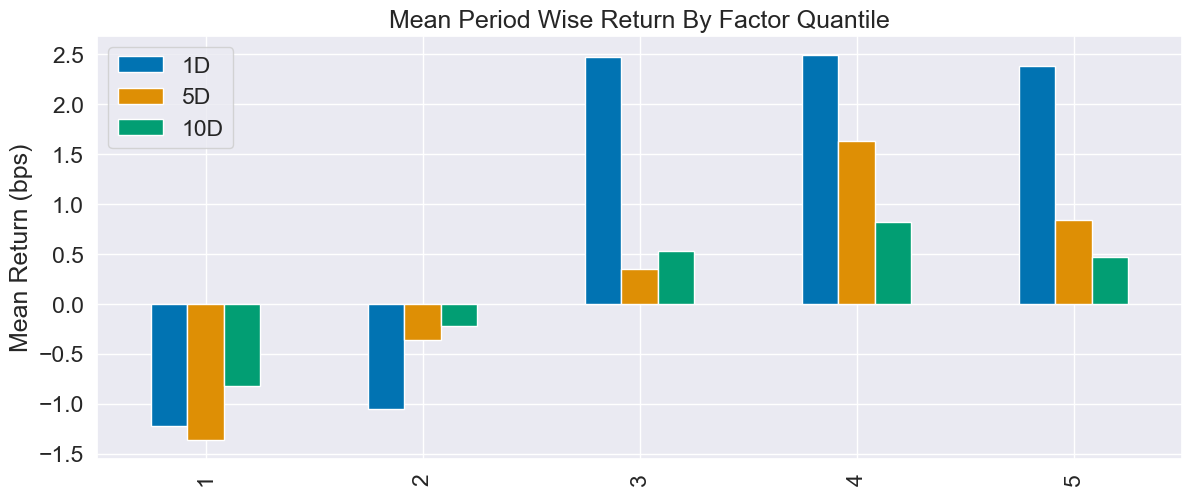

In [38]:
create_summary_tear_sheet(factor_data)